<a href="https://colab.research.google.com/github/yurisalesc/minicurso-python-para-engenharia-e-ia/blob/main/exemplos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [61]:
estudantes = {
    "Yuri": 20,
    "Ana": 16,
    "Tobias": 17,
    "Renato": 22,
    "Dayvson": 15,
    "João": 13,
    "Marcolino": 23,
}

In [4]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Gerando dados sintéticos para o curso
np.random.seed(42)
n_rows = 5000

data = {
    'ID_Pedido': range(1001, 1001 + n_rows),
    'Data': [datetime(2023, 1, 1) + timedelta(days=np.random.randint(0, 365)) for _ in range(n_rows)],
    'Produto': np.random.choice(['Laptop', 'Mouse', 'Monitor', 'Teclado', 'Headset'], n_rows),
    'Categoria': np.random.choice(['Eletrônicos', 'Acessórios'], n_rows),
    'Quantidade': np.random.randint(1, 5, n_rows),
    'Preco_Unitario': np.random.uniform(50, 5000, n_rows).round(2),
    'Regiao': np.random.choice(['Norte', 'Sul', 'Leste', 'Oeste'], n_rows),
    'Satisfacao_Cliente': np.random.randint(1, 6, n_rows)
}

df_original = pd.DataFrame(data)
df_original['Faturamento'] = df_original['Quantidade'] * df_original['Preco_Unitario']

# Salvar para simular leitura de arquivo
df_original.to_csv('vendas_curso.csv', index=False)
print('Arquivo vendas_curso.csv gerado com sucesso!')

Arquivo vendas_curso.csv gerado com sucesso!


In [6]:
df = pd.read_csv('vendas_curso.csv')

display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID_Pedido           5000 non-null   int64  
 1   Data                5000 non-null   object 
 2   Produto             5000 non-null   object 
 3   Categoria           5000 non-null   object 
 4   Quantidade          5000 non-null   int64  
 5   Preco_Unitario      5000 non-null   float64
 6   Regiao              5000 non-null   object 
 7   Satisfacao_Cliente  5000 non-null   int64  
 8   Faturamento         5000 non-null   float64
dtypes: float64(2), int64(3), object(4)
memory usage: 351.7+ KB


None

In [7]:
display(df.describe())

,ID_Pedido,Quantidade,Preco_Unitario,Satisfacao_Cliente,Faturamento
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,3500.500000,2.508400,2533.058278,3.064600,6325.619440
std,1443.520003,1.112734,1430.637842,1.432354,4763.059106
min,1001.000000,1.000000,51.250000,1.000000,51.630000
25%,2250.750000,2.000000,1288.755000,2.000000,2528.955000
50%,3500.500000,3.000000,2552.985000,3.000000,4925.980000
75%,4750.250000,3.000000,3779.232500,4.000000,9300.922500
max,6000.000000,4.000000,4999.630000,5.000000,19973.240000


In [9]:
df.head()

,ID_Pedido,Data,Produto,Categoria,Quantidade,Preco_Unitario,Regiao,Satisfacao_Cliente,Faturamento
0,1001,2023-04-13,Teclado,Eletrônicos,3,3099.69,Norte,1,9299.07
1,1002,2023-12-15,Mouse,Acessórios,3,985.63,Leste,3,2956.89
2,1003,2023-09-28,Teclado,Eletrônicos,2,999.84,Sul,3,1999.68
3,1004,2023-04-17,Laptop,Acessórios,4,3283.69,Norte,2,13134.76
4,1005,2023-03-13,Teclado,Eletrônicos,1,315.80,Oeste,5,315.80


In [18]:
clientes_norte = df[df["Regiao"] == "Norte"]
display(clientes_norte.info())

baixa_satisfacao = clientes_norte[clientes_norte["Satisfacao_Cliente"] <= 3]
display(baixa_satisfacao.info())

clientes_norte_baixa_satisfacao = df[(df["Regiao"] == "Norte") & (df["Satisfacao_Cliente"] <= 3)]
display(clientes_norte_baixa_satisfacao.info())

display(len(clientes_norte_baixa_satisfacao))

<class 'pandas.core.frame.DataFrame'>
Index: 1271 entries, 0 to 4997
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID_Pedido           1271 non-null   int64  
 1   Data                1271 non-null   object 
 2   Produto             1271 non-null   object 
 3   Categoria           1271 non-null   object 
 4   Quantidade          1271 non-null   int64  
 5   Preco_Unitario      1271 non-null   float64
 6   Regiao              1271 non-null   object 
 7   Satisfacao_Cliente  1271 non-null   int64  
 8   Faturamento         1271 non-null   float64
dtypes: float64(2), int64(3), object(4)
memory usage: 99.3+ KB


None

<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 4997
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID_Pedido           740 non-null    int64  
 1   Data                740 non-null    object 
 2   Produto             740 non-null    object 
 3   Categoria           740 non-null    object 
 4   Quantidade          740 non-null    int64  
 5   Preco_Unitario      740 non-null    float64
 6   Regiao              740 non-null    object 
 7   Satisfacao_Cliente  740 non-null    int64  
 8   Faturamento         740 non-null    float64
dtypes: float64(2), int64(3), object(4)
memory usage: 57.8+ KB


None

<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 4997
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID_Pedido           740 non-null    int64  
 1   Data                740 non-null    object 
 2   Produto             740 non-null    object 
 3   Categoria           740 non-null    object 
 4   Quantidade          740 non-null    int64  
 5   Preco_Unitario      740 non-null    float64
 6   Regiao              740 non-null    object 
 7   Satisfacao_Cliente  740 non-null    int64  
 8   Faturamento         740 non-null    float64
dtypes: float64(2), int64(3), object(4)
memory usage: 57.8+ KB


None

740

In [20]:
df['Data'] = pd.to_datetime(df['Data'])

,ID_Pedido,Data,Produto,Categoria,Quantidade,Preco_Unitario,Regiao,Satisfacao_Cliente,Faturamento
0,1001,2023-04-13,Teclado,Eletrônicos,3,3099.69,Norte,1,9299.07
1,1002,2023-12-15,Mouse,Acessórios,3,985.63,Leste,3,2956.89
2,1003,2023-09-28,Teclado,Eletrônicos,2,999.84,Sul,3,1999.68
3,1004,2023-04-17,Laptop,Acessórios,4,3283.69,Norte,2,13134.76
4,1005,2023-03-13,Teclado,Eletrônicos,1,315.80,Oeste,5,315.80
...,...,...,...,...,...,...,...,...,...
4995,5996,2023-02-25,Monitor,Acessórios,4,4200.49,Sul,1,16801.96
4996,5997,2023-12-26,Mouse,Eletrônicos,3,966.62,Oeste,1,2899.86
4997,5998,2023-04-20,Laptop,Eletrônicos,3,2796.47,Norte,2,8389.41
4998,5999,2023-07-11,Mouse,Eletrônicos,2,3625.05,Oeste,4,7250.10


In [21]:
print("1. Faturamento total por Categoria:")
display(df.groupby('Categoria')['Faturamento'].sum().reset_index())

1. Faturamento total por Categoria:


,Categoria,Faturamento
0,Acessórios,15677177.43
1,Eletrônicos,15950919.77


In [22]:
print("\n2. Quantidade média de itens por Produto:")
display(df.groupby('Produto')['Quantidade'].mean().reset_index())


2. Quantidade média de itens por Produto:


,Produto,Quantidade
0,Headset,2.493939
1,Laptop,2.482759
2,Monitor,2.534737
3,Mouse,2.524836
4,Teclado,2.506135


In [24]:
print("\n3. Média de Satisfação do Cliente por Região e Categoria:")
display(df.groupby(['Regiao', 'Categoria'])['Satisfacao_Cliente'].mean().unstack())


display(df.groupby(['Regiao', 'Categoria'])['Satisfacao_Cliente'].mean())


3. Média de Satisfação do Cliente por Região e Categoria:


Categoria,Acessórios,Eletrônicos
Regiao,,
Leste,3.122186,3.061350
Norte,3.012480,3.053968
Oeste,3.049231,3.054839
Sul,3.018771,3.146912


Regiao  Categoria  
Leste   Acessórios     3.122186
        Eletrônicos    3.061350
Norte   Acessórios     3.012480
        Eletrônicos    3.053968
Oeste   Acessórios     3.049231
        Eletrônicos    3.054839
Sul     Acessórios     3.018771
        Eletrônicos    3.146912
Name: Satisfacao_Cliente, dtype: float64

In [27]:
print("\n4. Faturamento total diário (apenas os 5 primeiros dias):")
display(df.groupby(df['Data'].dt.date)['Faturamento'].sum().head().reset_index())

print("\n5. Produto mais vendido (em quantidade) por Região:")
produto_mais_vendido_regiao_simples = df.loc[df.groupby('Regiao')['Quantidade'].idxmax()]
display(produto_mais_vendido_regiao_simples[['Regiao', 'Produto', 'Quantidade']])


4. Faturamento total diário (apenas os 5 primeiros dias):


,Data,Faturamento
0,2023-01-01,90199.40
1,2023-01-02,57555.99
2,2023-01-03,76643.06
3,2023-01-04,63650.27
4,2023-01-05,135624.34



5. Produto mais vendido (em quantidade) por Região:


,Regiao,Produto,Quantidade
19,Leste,Teclado,4
3,Norte,Laptop,4
70,Oeste,Teclado,4
11,Sul,Mouse,4


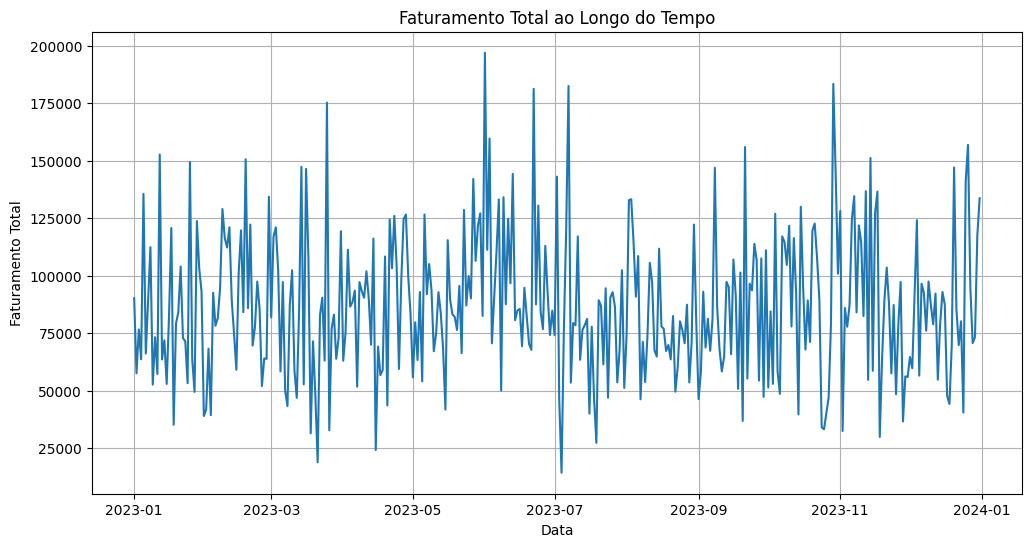

In [33]:
import matplotlib.pyplot as plt

# Agrupar faturamento por data para o gráfico de linha
faturamento_diario = df.groupby('Data')['Faturamento'].sum().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(faturamento_diario['Data'], faturamento_diario['Faturamento'])
plt.title('Faturamento Total ao Longo do Tempo')
plt.xlabel('Data')
plt.ylabel('Faturamento Total')
plt.grid(True)
plt.show()

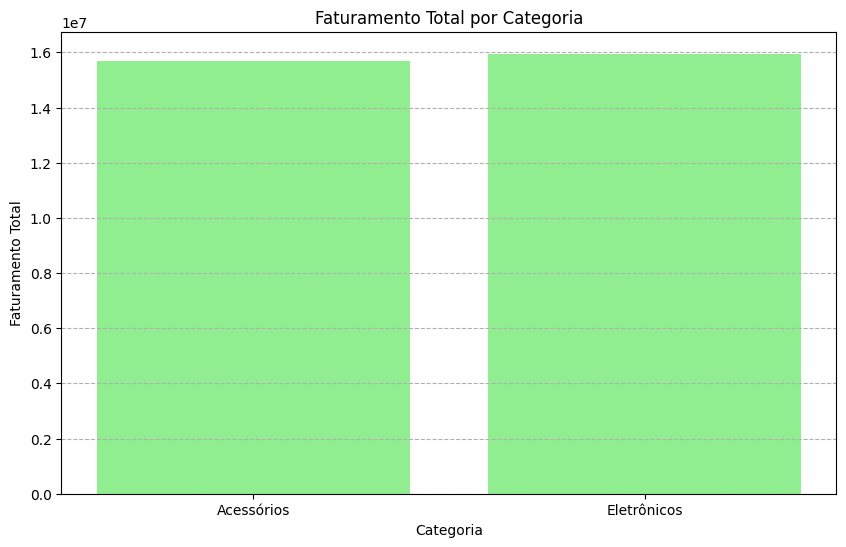

In [36]:
# 2. Distribuição de Faturamento por Categoria (Gráfico de Barras)
faturamento_por_categoria = df.groupby('Categoria')['Faturamento'].sum().reset_index()

plt.figure(figsize=(10, 6))
plt.bar(faturamento_por_categoria['Categoria'], faturamento_por_categoria['Faturamento'], color='lightgreen')
plt.title('Faturamento Total por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Faturamento Total')
plt.grid(axis='y', linestyle='--')
plt.show()

### Análise do Faturamento Total por Categoria

Este gráfico de barras exibe o faturamento total gerado por cada categoria de produto. Ele nos permite identificar rapidamente quais categorias são as mais lucrativas e onde o negócio deve focar seus esforços ou recursos. É uma visualização chave para a tomada de decisões estratégicas de produto e marketing.

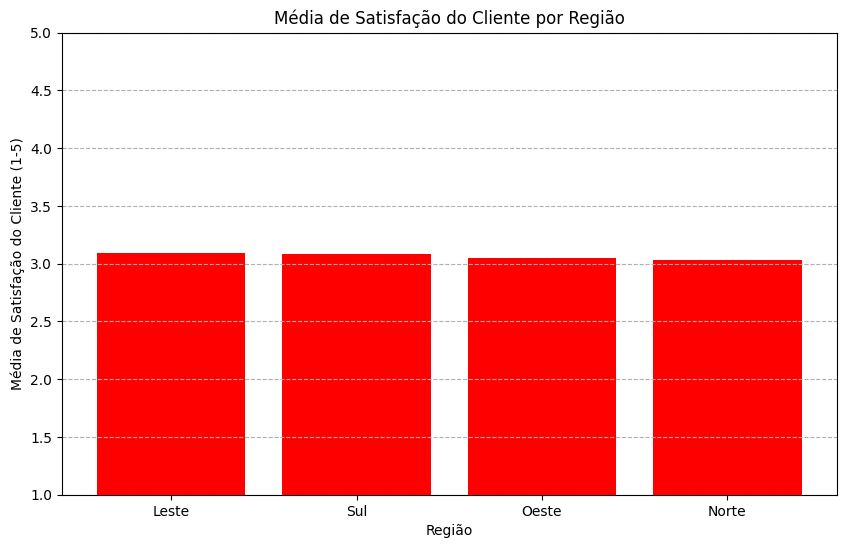

In [38]:
# 3. Média de Satisfação do Cliente por Região (Gráfico de Barras)
satisfacao_por_regiao = df.groupby('Regiao')['Satisfacao_Cliente'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
plt.bar(satisfacao_por_regiao['Regiao'], satisfacao_por_regiao['Satisfacao_Cliente'], color='red')
plt.title('Média de Satisfação do Cliente por Região')
plt.xlabel('Região')
plt.ylabel('Média de Satisfação do Cliente (1-5)')
plt.grid(axis='y', linestyle='--')
plt.ylim(1, 5) # Satisfação vai de 1 a 5
plt.show()

### Análise dos Produtos Mais Vendidos por Faturamento

Este gráfico de barras apresenta os produtos que geraram o maior faturamento total. É uma ferramenta essencial para identificar os produtos carro-chefe da empresa, que contribuem significativamente para a receita. Essa informação pode guiar decisões de estoque, marketing e desenvolvimento de produtos.

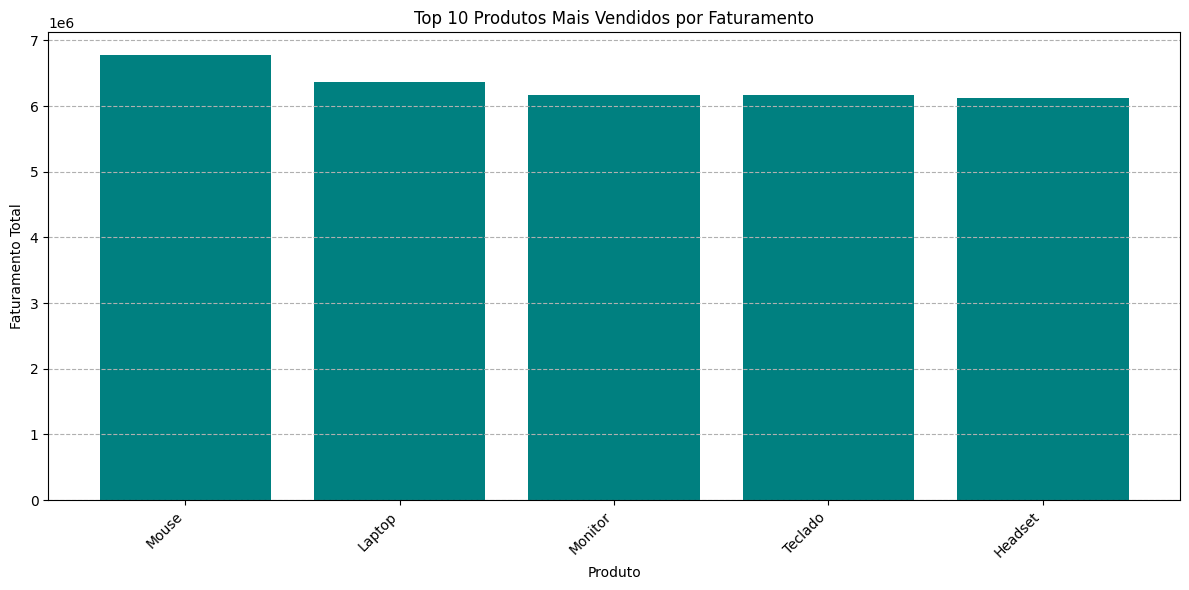

In [31]:
# 4. Produtos Mais Vendidos por Faturamento (Gráfico de Barras)
produtos_mais_vendidos_faturamento = df.groupby('Produto')['Faturamento'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 6))
plt.bar(produtos_mais_vendidos_faturamento['Produto'], produtos_mais_vendidos_faturamento['Faturamento'], color='teal')
plt.title('Top 10 Produtos Mais Vendidos por Faturamento')
plt.xlabel('Produto')
plt.ylabel('Faturamento Total')
plt.grid(axis='y', linestyle='--')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Análise da Distribuição de Satisfação do Cliente (Histograma)

Este histograma ilustra a distribuição das pontuações de satisfação do cliente (de 1 a 5). Ele é útil para entender a frequência de cada nível de satisfação, revelando se os clientes estão geralmente satisfeitos, insatisfeitos ou se há uma distribuição mais uniforme. Isso pode indicar a necessidade de investigar os extremos da satisfação.

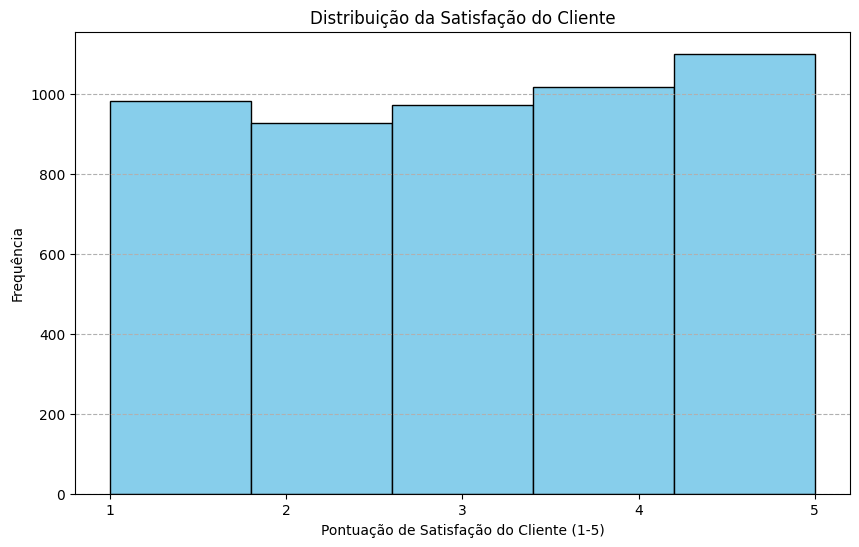

In [55]:
# 5. Distribuição de Satisfação do Cliente (Histograma)
plt.figure(figsize=(10, 6))
plt.hist(df['Satisfacao_Cliente'], bins=5, edgecolor='black', color='skyblue')
plt.title('Distribuição da Satisfação do Cliente')
plt.xlabel('Pontuação de Satisfação do Cliente (1-5)')
plt.ylabel('Frequência')
plt.xticks(range(1, 6))
plt.grid(axis='y', linestyle='--')
plt.show()

### Análise do Faturamento Total por Categoria (Gráfico de Pizza)

Este gráfico de pizza (pie chart) mostra a proporção do faturamento total contribuída por cada categoria de produto. É uma maneira eficaz de visualizar a composição do faturamento e identificar as categorias que dominam ou têm uma participação menor no total, complementando a visão do gráfico de barras já criado.

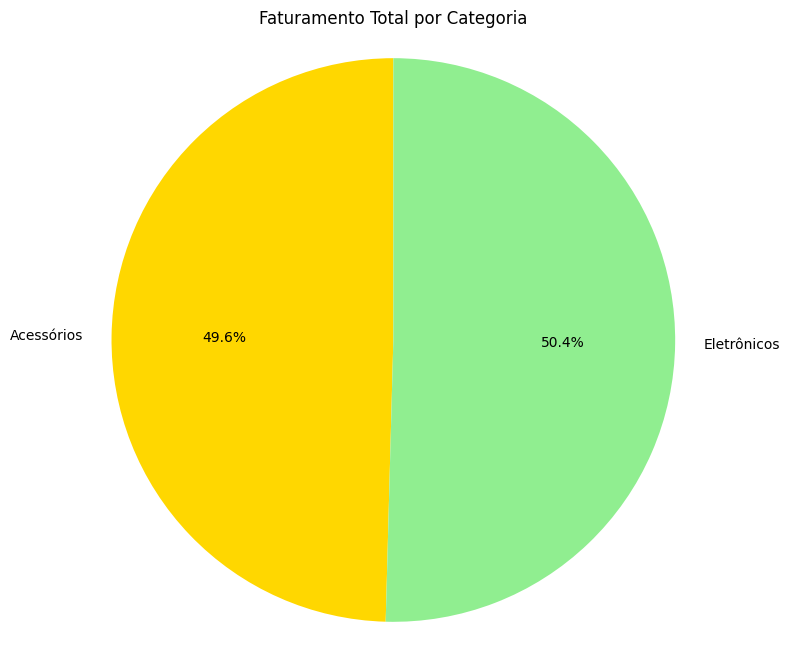

In [56]:
# 7. Faturamento Total por Categoria (Gráfico de Pizza)
faturamento_por_categoria = df.groupby('Categoria')['Faturamento'].sum()

plt.figure(figsize=(8, 8))
plt.pie(faturamento_por_categoria, labels=faturamento_por_categoria.index, autopct='%1.1f%%', startangle=90, colors=['gold', 'lightgreen'])
plt.title('Faturamento Total por Categoria')
plt.axis('equal')
plt.show()

### Análise da Relação entre Preço Unitário e Quantidade Vendida (Scatter Plot)

Este scatter plot (gráfico de dispersão) nos ajuda a visualizar a relação entre o preço unitário de um produto e a quantidade vendida. Podemos observar se há uma correlação, por exemplo, se produtos mais caros tendem a ser vendidos em menor quantidade, ou se existem *clusters* de produtos com comportamentos de venda específicos.

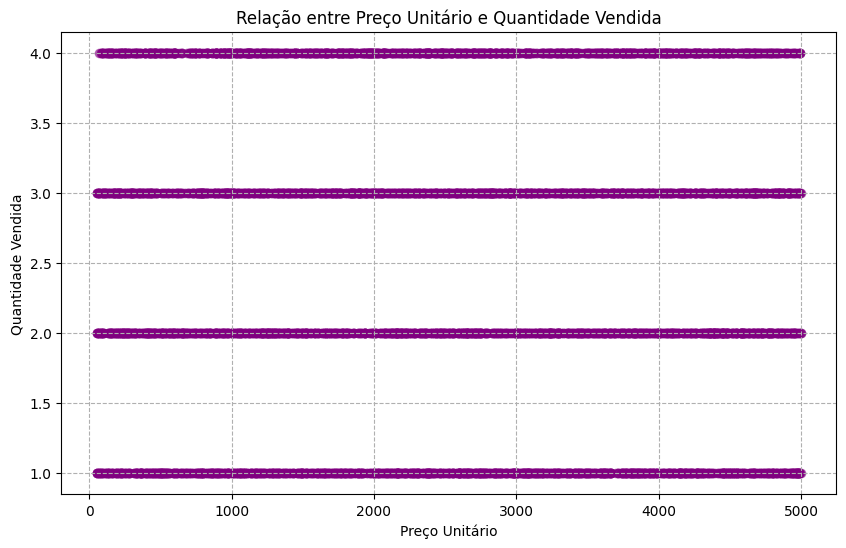

In [57]:
# 8. Relação entre Preço Unitário e Quantidade Vendida (Scatter Plot)
plt.figure(figsize=(10, 6))
plt.scatter(df['Preco_Unitario'], df['Quantidade'], alpha=0.5, color='purple')
plt.title('Relação entre Preço Unitário e Quantidade Vendida')
plt.xlabel('Preço Unitário')
plt.ylabel('Quantidade Vendida')
plt.grid(True, linestyle='--')
plt.show()

### Dashboard Completo de Análise de Vendas

Agora, vamos reunir alguns dos gráficos mais importantes em um único dashboard usando `matplotlib.pyplot.subplots()`. Isso nos permite ter uma visão geral e comparativa de diferentes aspectos dos dados de vendas em uma só imagem, facilitando a identificação de tendências e *insights* rapidamente.

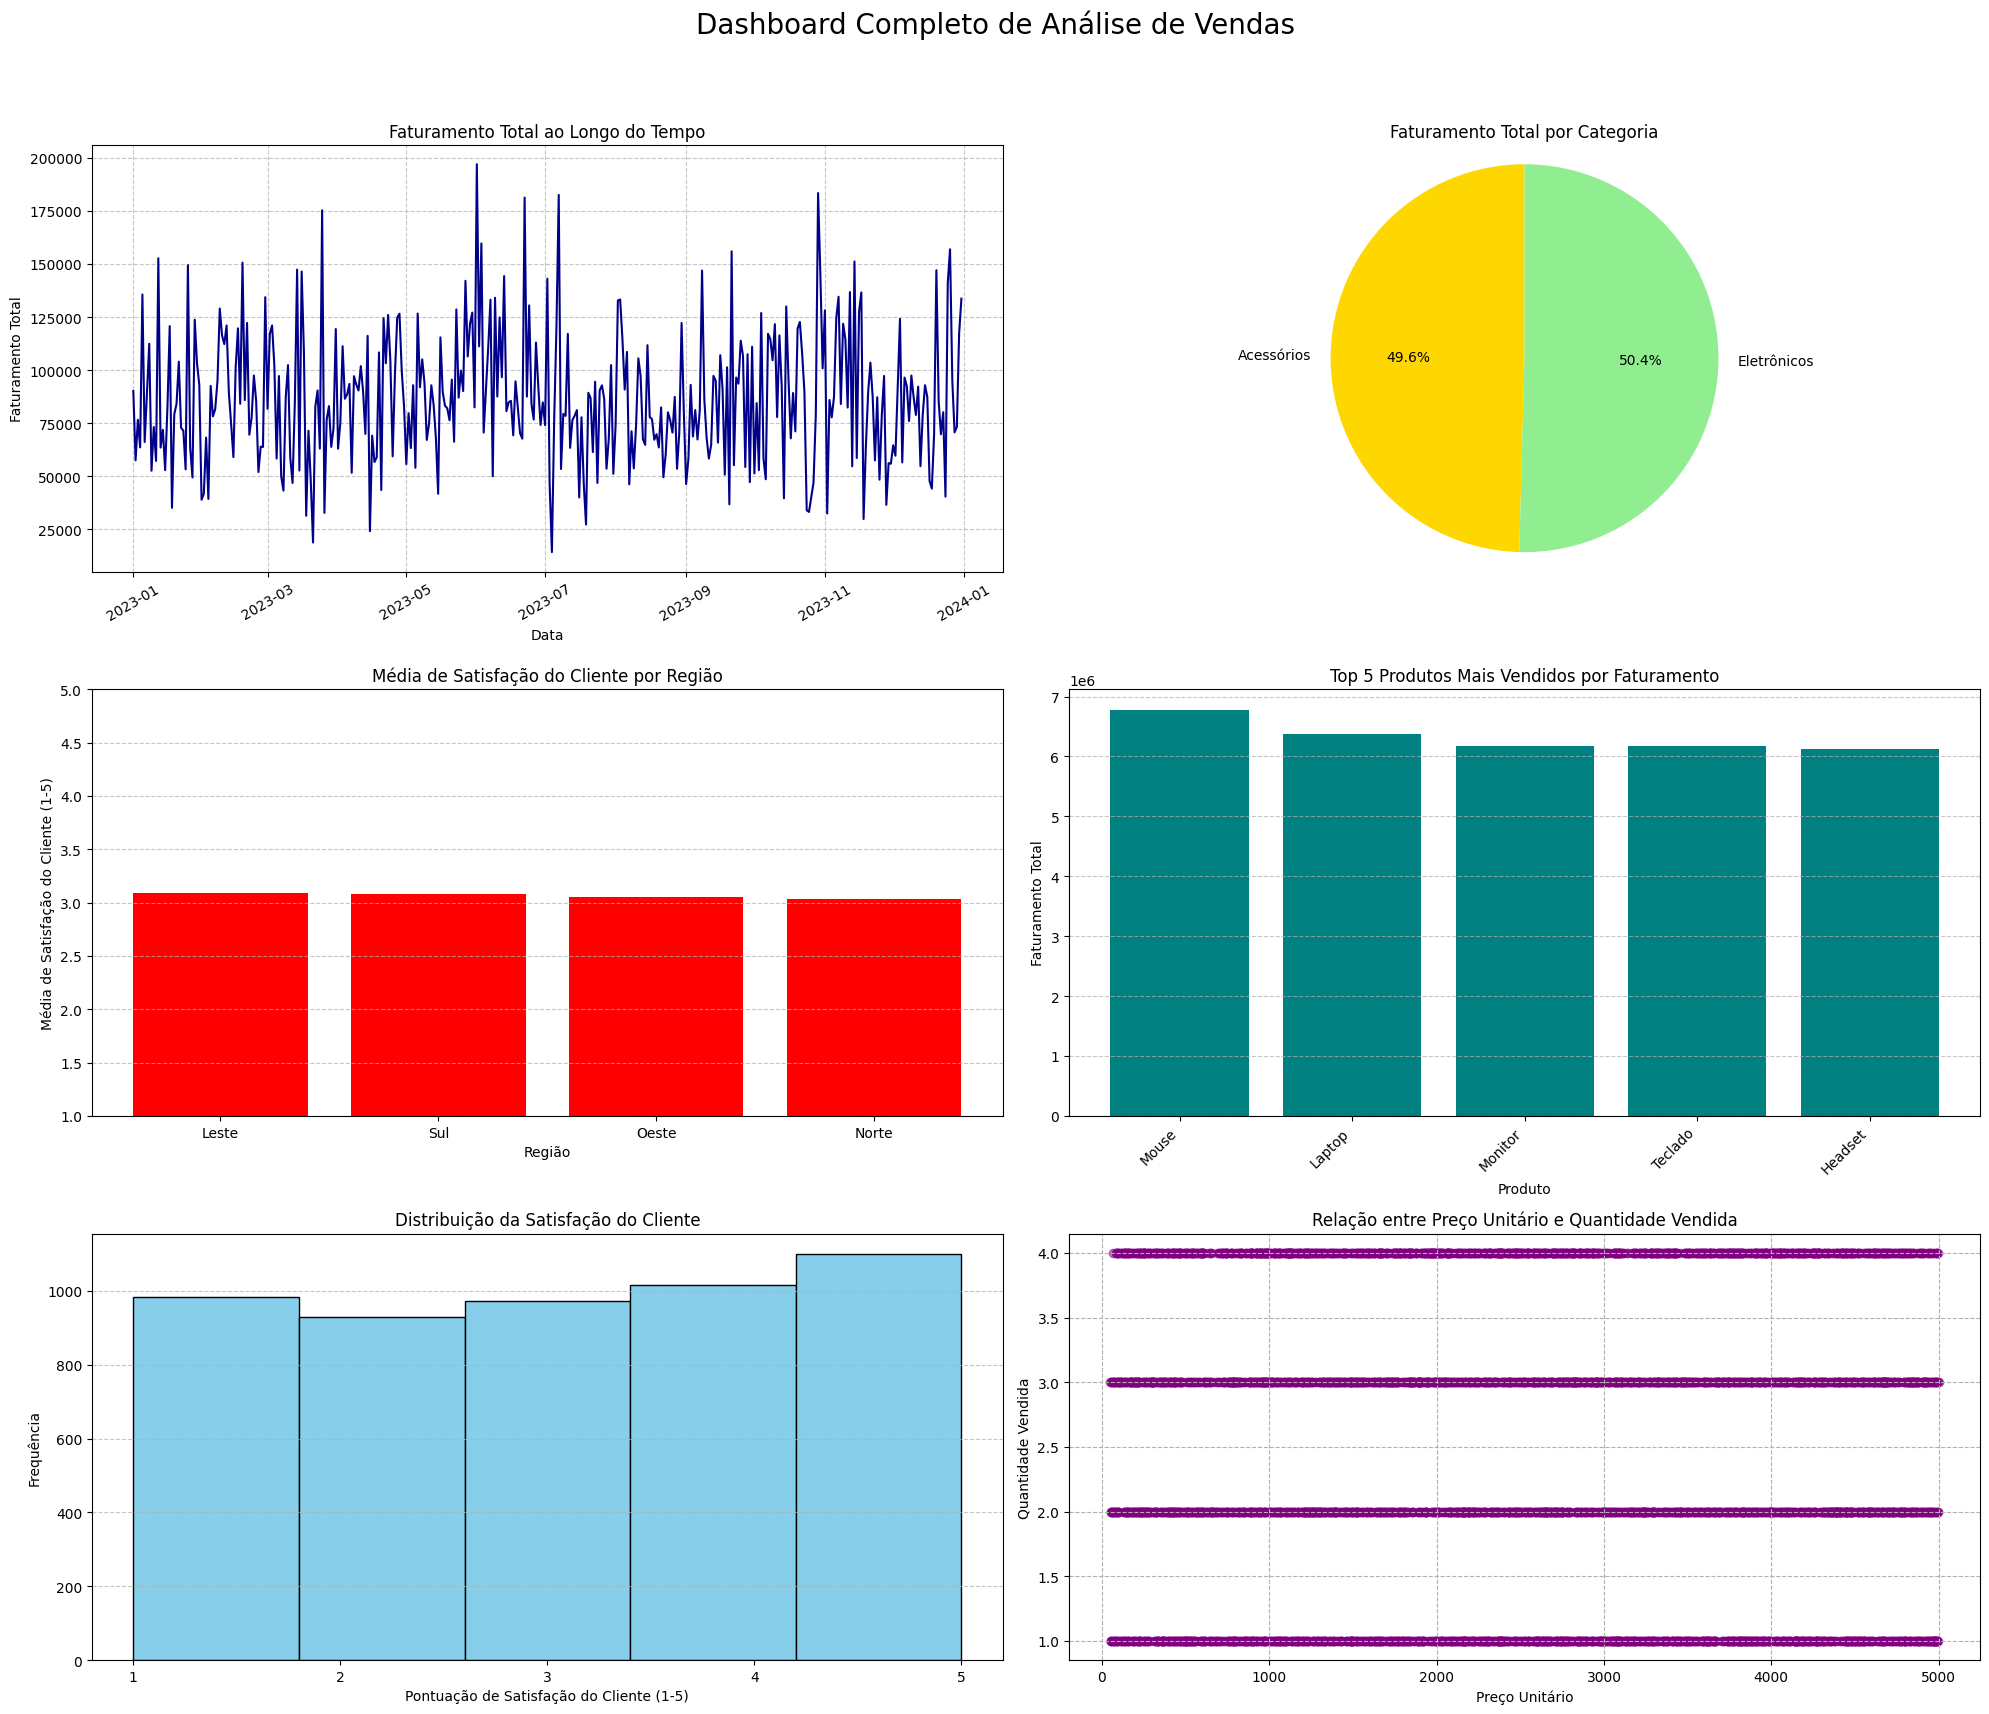

In [60]:
# Criando um Dashboard Completo

# Preparando os dados para os gráficos
faturamento_diario = df.groupby('Data')['Faturamento'].sum().reset_index()
faturamento_por_categoria = df.groupby('Categoria')['Faturamento'].sum()
satisfacao_por_regiao = df.groupby('Regiao')['Satisfacao_Cliente'].mean().sort_values(ascending=False).reset_index()
produtos_mais_vendidos_faturamento = df.groupby('Produto')['Faturamento'].sum().sort_values(ascending=False).head(5).reset_index()

# Configura a figura e os subplots
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(20, 18))
fig.suptitle('Dashboard Completo de Análise de Vendas', fontsize=20)

# Gráfico 1: Faturamento Total ao Longo do Tempo (Linha)
axes[0, 0].plot(faturamento_diario['Data'], faturamento_diario['Faturamento'], color='darkblue')
axes[0, 0].set_title('Faturamento Total ao Longo do Tempo')
axes[0, 0].set_xlabel('Data')
axes[0, 0].set_ylabel('Faturamento Total')
axes[0, 0].grid(True, linestyle='--', alpha=0.7)
plt.setp(axes[0, 0].xaxis.get_majorticklabels(), rotation=30)

# Gráfico 2: Faturamento Total por Categoria (Pizza) - Substituindo o gráfico de barras anterior
axes[0, 1].pie(faturamento_por_categoria, labels=faturamento_por_categoria.index, autopct='%1.1f%%', startangle=90, colors=['gold', 'lightgreen'])
axes[0, 1].set_title('Faturamento Total por Categoria')
axes[0, 1].axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

# Gráfico 3: Média de Satisfação do Cliente por Região (Barras)
axes[1, 0].bar(satisfacao_por_regiao['Regiao'], satisfacao_por_regiao['Satisfacao_Cliente'], color='red')
axes[1, 0].set_title('Média de Satisfação do Cliente por Região')
axes[1, 0].set_xlabel('Região')
axes[1, 0].set_ylabel('Média de Satisfação do Cliente (1-5)')
axes[1, 0].set_ylim(1, 5)
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.7)

# Gráfico 4: Top 5 Produtos Mais Vendidos por Faturamento (Barras)
axes[1, 1].bar(produtos_mais_vendidos_faturamento['Produto'], produtos_mais_vendidos_faturamento['Faturamento'], color='teal')
axes[1, 1].set_title('Top 5 Produtos Mais Vendidos por Faturamento')
axes[1, 1].set_xlabel('Produto')
axes[1, 1].set_ylabel('Faturamento Total')
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.7)
plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=45, ha='right')

# Gráfico 5: Distribuição da Satisfação do Cliente (Histograma)
axes[2, 0].hist(df['Satisfacao_Cliente'], bins=5, edgecolor='black', color='skyblue')
axes[2, 0].set_title('Distribuição da Satisfação do Cliente')
axes[2, 0].set_xlabel('Pontuação de Satisfação do Cliente (1-5)')
axes[2, 0].set_ylabel('Frequência')
axes[2, 0].set_xticks(range(1, 6))
axes[2, 0].grid(axis='y', linestyle='--', alpha=0.7)

# Gráfico 6: Relação entre Preço Unitário e Quantidade Vendida (Scatter Plot)
axes[2, 1].scatter(df['Preco_Unitario'], df['Quantidade'], alpha=0.5, color='purple')
axes[2, 1].set_title('Relação entre Preço Unitário e Quantidade Vendida')
axes[2, 1].set_xlabel('Preço Unitário')
axes[2, 1].set_ylabel('Quantidade Vendida')
axes[2, 1].grid(True, linestyle='--')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajusta o layout para evitar sobreposição, deixando espaço para o título principal
plt.show()